## Figure S4 — QHO limit and Transmon analogy

This notebook reproduces **Figure S4** of the supplementary material.

It studies the deep-modulation (large-$q$) limit of the Mathieu equation, which governs a negative-$F(x)$ periodic medium. In this limit the bound modes of each potential well converge to quantum harmonic oscillator (QHO) levels, in direct analogy with the transmon superconducting qubit (Josephson junction circuit).

The Transmon Hamiltonian $H = -4E_C \partial^2/\partial\varphi^2 - E_J\cos\varphi$ is discretized on a uniform $\varphi$-grid and diagonalized. The eigenvalues are compared with the exact Mathieu characteristic values $a_n$, $b_n$ and with the perturbative QHO correction $a_n^{\rm QHO} = 2(n+\tfrac{1}{2})\sqrt{4q} - 2q$.

In [1]:
import numpy as np
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [2]:
def equation_lin(t, y, toto, titi):  
    qq, pp  = y
    #dydt = [pp, -(toto-2*titi*np.cos(2*t))*qq]
    dydt = [pp, -(toto+2*titi*np.cos(2*(t-np.pi/2)))*qq]
    return dydt


In [3]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [4]:
def compute_energy(fft_wave, k):
    # Compute the squared amplitude of the FFT (energy density in Fourier space)
    amplitude_squared = np.abs(fft_wave)**2
    
    # Compute the spacing in k-space (assumes uniform sampling in k)
    dk = np.abs(k[1] - k[0])  # Assumes k is sorted and evenly spaced
    
    # Integrate energy density over all wavenumbers
    total_energy = np.sum(amplitude_squared) * dk
    
    return total_energy

In [5]:
def sol_comp_mode_floquet(t, y, a, q, sn):
    JJ = np.array([ [0.,1 ],
                       [-(a+2*q*np.cos(2*(t-np.pi/2))),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



In [6]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

In [7]:
def compute_hill_eigenvalues1(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    Hmax = 20
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute eigenvalues and eigenvectors
    eigtot, V = np.linalg.eig(HILL)
    eigtot = eigtot[np.argsort(np.imag(eigtot))]  # Sort eigenvalues by imaginary part

    # Weighted arithmetic mean (center of mass) calculation
    XX = np.repeat(np.arange(-Hmax, Hmax + 1), nstate)
    abs_V = np.abs(V)
    Wmean = np.sum(XX[:, None] * abs_V, axis=0) / np.sum(abs_V, axis=0)

    # Sort by weighted arithmetic mean
    sorted_indices = np.argsort(Wmean)
    Wmean_sorted = Wmean[sorted_indices]

    # Filter based on balanced eigenvectors
    ind2 = np.where((np.round(Wmean_sorted, 6) <= 0.5) & (np.round(Wmean_sorted, 6) > -0.5))[0]

    # Select the most converged eigenvalues and eigenvectors
    if len(ind2) == nstate:
        # Further sort by the absolute imaginary part of eigenvalues
        ind3 = np.argsort(np.abs(np.imag(eigtot[sorted_indices[ind2]])))
        Fexponents = eigtot[sorted_indices[ind2[ind3]]]
        VecHill = V[:, sorted_indices[ind2[ind3]]]
    else:
        # If not enough converged eigenvalues, return NaN arrays
        Fexponents = np.full((nstate,), np.nan + 1j * np.nan)
        VecHill = np.full((nstate * (2 * Hmax + 1), nstate), np.nan + 1j * np.nan)

    return Fexponents, VecHill


In [8]:
def compute_hill_eigenvalues2(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    solfinal = np.zeros(nstate, dtype=complex)
    Hmax = 12
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute the eigenvalues
    eighill = np.linalg.eigvals(HILL)
    
    # Filter eigenvalues based on the imaginary part condition
    condition = np.abs(np.imag(eighill)) < (np.pi / TT + 10**(-Hmax))
    solhill = eighill[condition]
    
    if solhill.size == nstate:
        solfinal = solhill
    elif solhill.size == 2*nstate:
        solfinal[0] = np.abs(np.real(solhill[0])) + 1j*np.abs(np.imag(solhill[0]))
        solfinal[1] = -solfinal[0]
            
    return solfinal

In [9]:
def equation_a(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_a(nn, q) - (2 * s0 * q / s1)

def equation_b(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_b(nn, q) - (2 * s0 * q / s1)

def solve_mathieu(nn, s0, s1, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solutiona = []
    solutionb = []
    for guess in initial_guesses:
        sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sola, solutiona, atol=1e-15)):  # Avoid duplicate roots
            solutiona.append(sola)
        if not any(np.isclose(solb, solutionb, atol=1e-15)):  # Avoid duplicate roots
            solutionb.append(solb)    
    return [solutiona,solutionb]


### Mathieu characteristic values over a wide $q$ range

Computes $a_n(q)$ and $b_n(q)$ for $n = 0\ldots 4$ over $q \in [0.1, 10^4]$ (1 M points). Also computes the QHO approximation $a_n^{\rm QHO} = 2(n+\tfrac{1}{2})\sqrt{q} - 2q$. These arrays feed the convergence plot below.

In [10]:
qq = np.linspace(0.1,10000,1000000)
#qq = np.linspace(0.1,10000,100000)
A0e0 = sp.mathieu_a(0,qq)
A0o1 = sp.mathieu_b(1,qq)
A0e1 = sp.mathieu_a(1,qq)
A0o2 = sp.mathieu_b(2,qq)
A0e2 = sp.mathieu_a(2,qq)
A0o3 = sp.mathieu_b(3,qq)
A0e3 = sp.mathieu_a(3,qq)
A0o4 = sp.mathieu_b(4,qq)


a0 = 4*(0+0.5)*np.sqrt(qq)-2*qq
a1 = 4*(1+0.5)*np.sqrt(qq)-2*qq
a2 = 4*(2+0.5)*np.sqrt(qq)-2*qq
a3= 4*(3+0.5)*np.sqrt(qq)-2*qq



### Transmon eigenvalue sweep — heavy computation

**Skip if `Map_transmon_numpoints_3000.npy` already exists on disk.**

Diagonalises the Transmon Hamiltonian for 1000 values of $q = E_J/(4E_C) \in [0.1, 10^4]$ and saves the four lowest eigenvalues to `Map_transmon_numpoints_3000.npy`.

In [ ]:
# Parameters for the transmon
qtestlist = np.logspace(-1, 4, 1000)

tran0 = np.zeros(qtestlist.size)
tran1 = np.zeros(qtestlist.size)
tran2 = np.zeros(qtestlist.size)
tran3 = np.zeros(qtestlist.size)

E_C = 1.0  # Charging energy
num_points = 3000  # Number of grid points for φ
phi_max = np.pi  # Range for φ

# Discretize the φ range
phi = np.linspace(-phi_max, phi_max, num_points)
dphi = phi[1] - phi[0]

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

inc = -1
for qtest in qtestlist:
    inc = inc + 1
    print(inc)
    # Potential term: V(phi) = -E_J * cos(phi)
    E_J = 2*qtest*E_C  # Josephson energy
    V = -E_J * np.cos(phi)


    # Full Hamiltonian: H = T + V
    H = T + diags([V], [0])

    # Solve for eigenvalues and eigenvectors
    eigenvalues, eigenvectors = eigh(H.toarray())
    eigenvalues = eigenvalues[:4]  # Only take the first 10 eigenvalues
    tran0[inc] = eigenvalues[0]
    tran1[inc] = eigenvalues[1]
    tran2[inc] = eigenvalues[2]
    tran3[inc] = eigenvalues[3]

    
    
with open('Map_transmon_numpoints_3000.npy', 'wb') as f:
    np.save(f, qtestlist)
    np.save(f, tran0)
    np.save(f, tran1)
    np.save(f, tran2)
    np.save(f, tran3)


### → Figure S4a — QHO convergence of Mathieu / Transmon eigenvalues

Loads the precomputed Transmon eigenvalues and plots $a_n - a_n^{\rm QHO}$ versus $2q$ (log scale). Black bands: exact Mathieu stop bands; green dots: Transmon numerical eigenvalues; red lines: perturbative correction $-\tfrac{1}{4} - n(n+1)/2$.

Produces `Convergences_Mathieu.png` → **Fig S4a**.

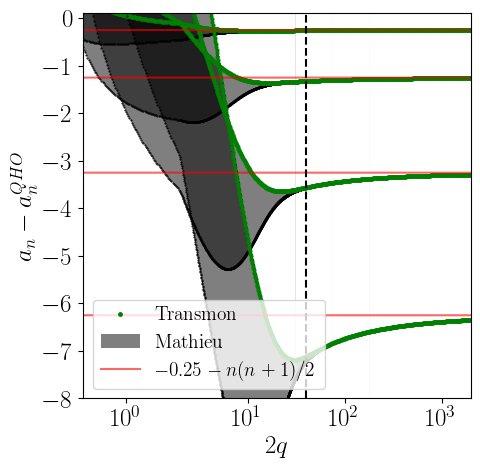

In [12]:
with open('Map_transmon_numpoints_3000.npy', 'rb') as f:
    qtestlist = np.load(f)
    tran0 = np.load(f)
    tran1 = np.load(f)
    tran2 = np.load(f)
    tran3 = np.load(f)


a0t = 4*(0+0.5)*np.sqrt(qtestlist)-2*qtestlist
a1t = 4*(1+0.5)*np.sqrt(qtestlist)-2*qtestlist
a2t = 4*(2+0.5)*np.sqrt(qtestlist)-2*qtestlist
a3t = 4*(3+0.5)*np.sqrt(qtestlist)-2*qtestlist


qtest = 20
fonty = 18
fig1 = plt.figure(1, figsize=(5, 5))
plt.rc('text', usetex=True)

plt.plot(np.NaN, np.NaN, 'g.',markersize=5.,label=r'$\mathrm{Transmon}$')

plt.plot(2*qq, A0e0-a0, 'k.',markersize=1.)
plt.plot(2*qq, A0o1-a0, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran0-a0t, 'g.',markersize=4.)
plt.fill_between(2*qq,A0e0-a0, A0o1-a0, facecolor='k',alpha=0.5,label=r'$\mathrm{Mathieu}$')
plt.plot(2*qq, A0e1-a1, 'k.',markersize=1.)
plt.plot(2*qq, A0o2-a1, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran1-a1t, 'g.',markersize=4.)
plt.fill_between(2*qq,A0e1-a1, A0o2-a1, facecolor='k',alpha=0.5)
plt.plot(2*qq, A0e2-a2, 'k.',markersize=1.)
plt.plot(2*qq, A0o3-a2, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran2-a2t, 'g.',markersize=4.)
plt.fill_between(2*qq,A0e2-a2, A0o3-a2, facecolor='k',alpha=0.5)
plt.plot(2*qq, A0e3-a3, 'k.',markersize=1.)
plt.plot(2*qq, A0o4-a3, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran3-a3t, 'g.',markersize=4.)
plt.fill_between(2*qq,A0e3-a3, A0o4-a3, facecolor='k',alpha=0.5)
plt.plot(2*qq,-0.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6,label=r'$-0.25-n(n+1)/2$')
plt.plot(2*qq,-1.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6)
plt.plot(2*qq,-3.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6)
plt.plot(2*qq,-6.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6)

plt.axvline(x=2*qtest, color='k', linestyle='--', alpha=1)

plt.xlabel('$2q$',fontsize=fonty)
plt.ylabel(r'$a_n - a^{QHO}_n$',fontsize=fonty) 
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(2*qq[0], 2e3)   # set the ylim to ymin, ymax
plt.ylim(-8., 0.1)   # set the ylim to ymin, ymax
plt.xscale('symlog')   
plt.legend(fontsize=fonty-4, loc='best')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Convergences_Mathieu.png', format='png', dpi=1000,bbox_inches='tight')


### Mathieu stability chart ($a_n$ vs $q$)

Plots the raw Mathieu characteristic values $a_n(q)$, $b_n(q)$ and the QHO approximation lines over the full range. Preliminary check for Fig S4a.

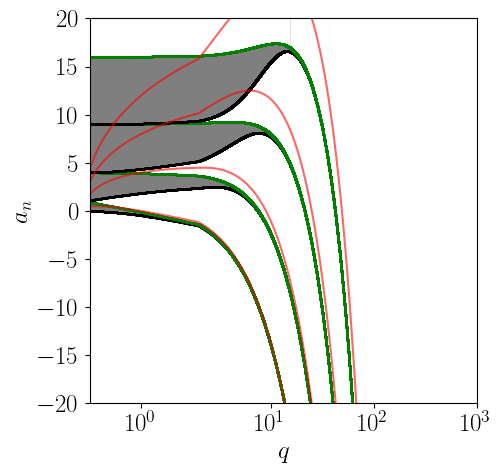

In [13]:
fonty = 18
fig2 = plt.figure(2, figsize=(5, 5))
plt.rc('text', usetex=True)

plt.plot(qq, A0e0, 'k.',markersize=2.)
plt.plot(qq, A0o1, 'g.',markersize=2.)
plt.fill_between(qq,A0e0, A0o1, facecolor='k',alpha=0.5)
plt.plot(qq, A0e1, 'k.',markersize=2.)
plt.plot(qq, A0o2, 'g.',markersize=2.)
plt.fill_between(qq,A0e1, A0o2, facecolor='k',alpha=0.5)
plt.plot(qq, A0e2, 'k.',markersize=2.)
plt.plot(qq, A0o3, 'g.',markersize=2.)
plt.fill_between(qq,A0e2, A0o3, facecolor='k',alpha=0.5)
plt.plot(qq, A0e3, 'k.',markersize=2.)
plt.plot(qq, A0o4, 'g.',markersize=2.)
plt.fill_between(qq,A0e3, A0o4, facecolor='k',alpha=0.5)
plt.plot(qq,a0,'r-',markersize=2.,alpha=0.6)
plt.plot(qq,a1,'r-',markersize=2.,alpha=0.6)
plt.plot(qq,a2,'r-',markersize=2.,alpha=0.6)
plt.plot(qq,a3,'r-',markersize=2.,alpha=0.6)


plt.xlabel('$q$',fontsize=fonty)
plt.ylabel(r'$a_n$',fontsize=fonty) 
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(qq[0], 1e3)   # set the ylim to ymin, ymax
plt.ylim(-20., 20)   # set the ylim to ymin, ymax
plt.xscale('symlog')
fig2 = plt.gcf()
plt.show()

#fig2.savefig('toto.png', format='png', dpi=1000,bbox_inches='tight')


### → Figure S4 — Transmon potential, Mathieu bands, and QHO approximation

Diagonalizes the Transmon Hamiltonian at $q = E_J/(4E_C) = 20$ and plots:
- The cosine potential $V(\varphi) = -E_J\cos\varphi$ (green)
- The parabolic QHO approximation with perturbative correction (red)
- Mathieu characteristic values $a_n$ (black bands) delimiting stop bands

Produces `Transmon_schrodinger_approx_bis.png` → **Fig S4**.

[-31.31339741 -14.49111706   1.16052624  15.49304153  28.46304799]
[-31.313390070336514, -14.491301425174816, 1.1542828852467468, 15.395810912805139, 27.59457815461195] [-31.313386166912924, -14.491063255980725, 1.1607056791652275, 15.493977576989293, 28.468221325102682]


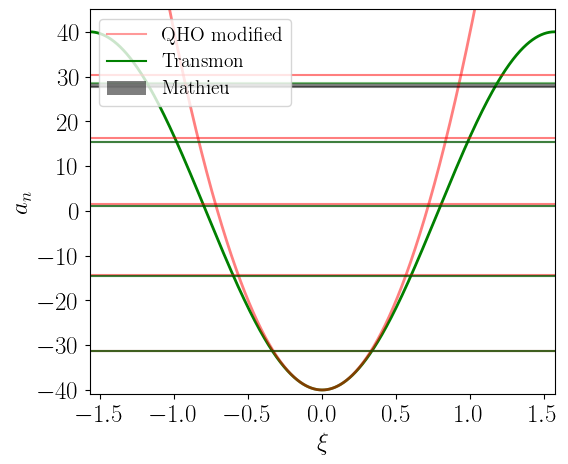

In [14]:
# Parameters for the transmon
qtest = 20
E_C = 1.0  # Charging energy
E_J = 2*qtest*E_C  # Josephson energy
num_points = 2000  # Number of grid points for φ
phi_max = np.pi  # Range for φ

# Discretize the φ range
phi = np.linspace(-phi_max, phi_max, num_points)
dphi = phi[1] - phi[0]

# Potential term: V(phi) = -E_J * cos(phi)
V = -E_J * np.cos(phi)

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

# Full Hamiltonian: H = T + V
H = T + diags([V], [0])

# Solve for eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(H.toarray())
eigenvalues = eigenvalues[:5]  # Only take the first 10 eigenvalues
eigenvectors = eigenvectors[:, :5]
print(eigenvalues)


# Calculate characteristic values (eigenvalues) for the first few Mathieu functions
n_values = range(5)  # Compute for n = 0, 1, 2, 3
eig_even = [E_C * mathieu_a(n, qtest) for n in n_values]
eig_odd = [E_C * mathieu_b(n+1, qtest) for n in n_values]
print(eig_even,eig_odd)

amp = 140
# Plot the potential and eigenfunctions
fonty = 18
fig3 = plt.figure(figsize=(6, 5))
plt.rc('text', usetex=True)

plt.plot(phi/2, -E_J * np.cos(phi),'g-',linewidth=2)
plt.plot(phi/2, -2*qtest+4*qtest*(phi/2)**2,'r-',linewidth=2,alpha=0.5)
for i in range(5):
    aHQOcorrec = 2*(i+0.5)*np.sqrt(4*qtest)-2*qtest-(i*(i+1)/2+0.25)
    #aHQOcorrec = 2*(i+0.5)*np.sqrt(4*qtest)-2*qtest
    plt.plot([-np.pi,np.pi], [aHQOcorrec,aHQOcorrec], 'r-',alpha=0.5)
    #plt.plot([-np.pi,np.pi], [eigenvalues[i],eigenvalues[i]], 'g:')
    plt.plot(np.array([-phi_max,phi_max]),np.array([eig_even[i],eig_even[i]]),'k-',alpha=0.5) 
    plt.plot(np.array([-phi_max,phi_max]),np.array([eig_odd[i],eig_odd[i]]),'g-',alpha=0.5)
    plt.fill_betweenx(np.array([eig_even[i],eig_odd[i]]),np.array([-phi_max,-phi_max]), np.array([phi_max,phi_max]), facecolor='k',alpha=0.5)
    #plt.plot(phi/2, eigenvectors[:, i]*amp + eigenvalues[i],'g-')
    
plt.plot([np.NaN,np.NaN], [np.NaN,np.NaN], 'r-',label=r'$\mathrm{QHO}$ $\mathrm{modified}$',alpha=0.4)
plt.plot([np.NaN,np.NaN], [np.NaN,np.NaN], 'g-',label=r'$\mathrm{Transmon}$')
plt.fill_betweenx(np.array([100,200]),np.array([-phi_max,-phi_max]), np.array([phi_max,phi_max]), 
                  facecolor='k',alpha=0.5,label=r'$\mathrm{Mathieu}$')
   

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-phi_max/2, phi_max/2)
plt.ylim(-2*qtest-1,2*qtest+5)
#plt.ylim(-2.5,-2)
#plt.ylim(7.5,8)
plt.xlabel(r'$\xi$', fontsize=fonty)
plt.ylabel('$a_n$', fontsize=fonty)
plt.legend(fontsize=fonty-4, loc='upper left')
plt.show()

fig3.savefig('Transmon_schrodinger_approx_bis.png', format='png', dpi=1000,bbox_inches='tight')



#fig4 = plt.figure(figsize=(10, 6))
#plt.plot(phi, eigenvectors[:, 0]*30, label=f"Eigenstate {0}")

## By Arnaud Lazarus - 06/13/2026